# Customer Churn Prediction

# 5. Model Training

## Business Objective

The objective of this phase is to build a machine learning model that can predict whether a customer is likely to churn.

Predicting churn enables businesses to take proactive actions such as targeted promotions, personalized support, and retention campaigns before customers leave.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
X = pd.read_csv("../data/processed/X_scaled.csv")

y = pd.read_csv("../data/processed/y.csv")

In [4]:
y = y.squeeze()

type(y)

pandas.Series

## 5.1 Train-Test Split

### Why split the dataset?

The dataset is divided into training and testing sets to evaluate the model's ability to generalize to unseen data.

- **Training Set:** Used to train the machine learning model.
- **Testing Set:** Used to evaluate model performance on unseen data.

An 80:20 split is commonly used in machine learning because it provides sufficient data for training while reserving a meaningful portion for evaluation.

In [5]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features : (5625, 30)
Testing Features  : (1407, 30)

Training Target : (5625,)
Testing Target  : (1407,)


## 5.2 Logistic Regression

### Why Logistic Regression?

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

In this project, the model predicts whether a customer will:

- **0 → Not Churn**
- **1 → Churn**

It serves as a strong baseline model because it is simple, interpretable, and computationally efficient.

In [7]:
# Create Logistic Regression model

logistic_model = LogisticRegression(
    random_state=42
)

In [8]:
# Train the model

logistic_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [9]:
# Predict on test data
y_pred = logistic_model.predict(X_test)

In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.8038
Precision : 0.6494
Recall    : 0.5695
F1 Score  : 0.6068


## 5.4 Confusion Matrix

### What is a Confusion Matrix?

A confusion matrix summarizes the performance of a classification model by comparing predicted values with actual values.

It helps identify:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

These values provide deeper insight into model performance than accuracy alone.

In [11]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[918, 115],
       [161, 213]])

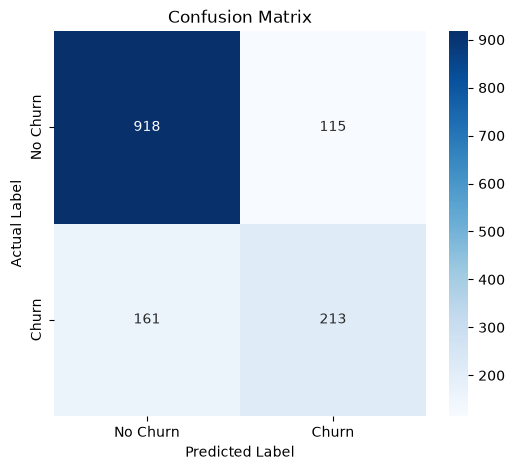

In [12]:
# Visualize confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

## 5.5 Classification Report

### What is a Classification Report?

A classification report summarizes the performance of a classification model using:

- Precision
- Recall
- F1-score
- Support

It provides a detailed evaluation for each class and helps assess how well the model predicts both churn and non-churn customers.

In [13]:
# Display classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## 5.6 ROC Curve and AUC Score

### What is the ROC Curve?

The Receiver Operating Characteristic (ROC) Curve evaluates a classification model across different probability thresholds.

It plots:

- True Positive Rate (Recall)
- False Positive Rate

The Area Under the Curve (AUC) summarizes the model's ability to distinguish between churn and non-churn customers.

An AUC closer to 1 indicates better model performance.

In [14]:
# Predict probability of churn

y_prob = logistic_model.predict_proba(X_test)[:,1]

y_prob[:10]

array([0.01799512, 0.59142853, 0.00492599, 0.20140777, 0.10299099,
       0.47059504, 0.02647034, 0.16521425, 0.67634759, 0.01578452])

In [15]:
auc = roc_auc_score(y_test, y_prob)

print(f"AUC Score : {auc:.4f}")

AUC Score : 0.8360


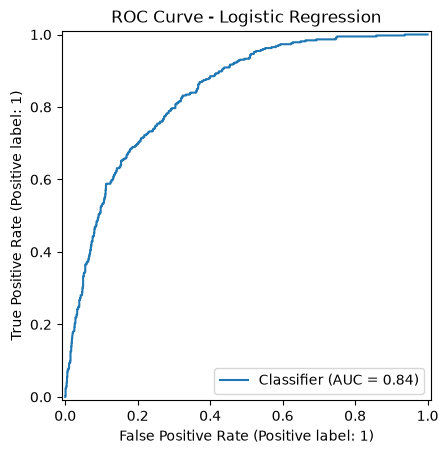

In [16]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

## 5.7 Cross Validation

Cross-validation evaluates model performance across multiple train-test splits.

Instead of relying on a single split, the dataset is divided into several folds, allowing the model to be trained and validated multiple times.

This provides a more reliable estimate of model performance and reduces the likelihood of results being dependent on one particular split.

In [17]:
cv_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_scores)

print()

print(f"Mean Accuracy : {cv_scores.mean():.4f}")
print(f"Standard Deviation : {cv_scores.std():.4f}")

Cross Validation Scores:
[0.80241649 0.81236674 0.79089616 0.81009957 0.8029872 ]

Mean Accuracy : 0.8038
Standard Deviation : 0.0075


### Business Interpretation

The Logistic Regression model achieved a mean cross-validation accuracy of **80.38%** with a standard deviation of **0.75%**.

The low variation across the five folds indicates that the model generalizes well and performs consistently on different subsets of customer data. This suggests that the model is unlikely to be overfitting and provides reliable baseline performance for churn prediction.

# 5.8 Create Reusable Evaluation Function

Instead of writing evaluation code for every machine learning model separately, we create a reusable function.

This improves code readability, reduces duplication, and makes it easy to compare multiple machine learning models using the same evaluation metrics.

In [18]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate a classification model using common performance metrics.
    """

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print("=" * 50)
    print(f"Model : {model.__class__.__name__}")
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC Score: {auc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model.__class__.__name__}")

    plt.show()

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob
    )

    plt.title(f"ROC Curve - {model.__class__.__name__}")
    plt.show()

    return {
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": auc
    }

Model : LogisticRegression
Accuracy : 0.8038
Precision: 0.6494
Recall   : 0.5695
F1 Score : 0.6068
AUC Score: 0.8360

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



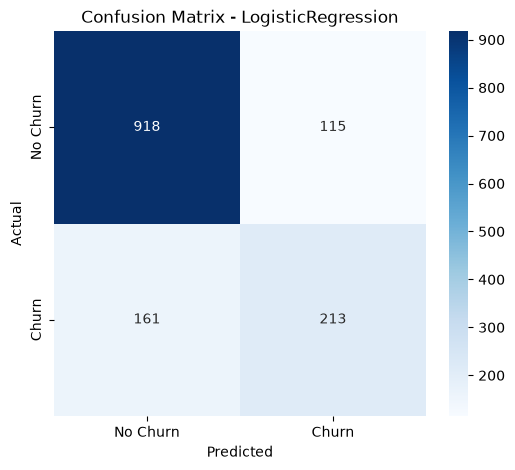

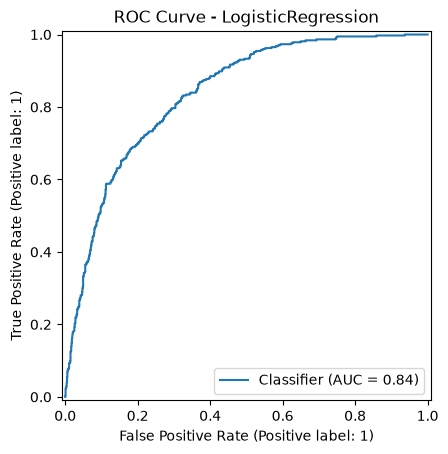

In [19]:
results_lr = evaluate_model(
    logistic_model,
    X_test,
    y_test
)

In [20]:
results_df = pd.DataFrame([results_lr])

results_df.to_csv(
    "../results/logistic_regression_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [21]:
import joblib

joblib.dump(
    logistic_model,
    "../models/logistic_regression.pkl"
)

print("Model saved successfully!")

Model saved successfully!
